In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
# Dataset
# For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from here.

# You can do it with wget:

df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
#The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

# Preparing the dataset
# Use only the following columns:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']
# EDA
for col in df[base]:
    # Primeiro exibimos para cada coluna o nome da coluna, as informações unicas quantas informações unicas possui.
    print(col)

engine_displacement
horsepower
vehicle_weight
model_year


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df = pd.read_csv(url)

# usar somente estas colunas
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'
df = df[base + [target]]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


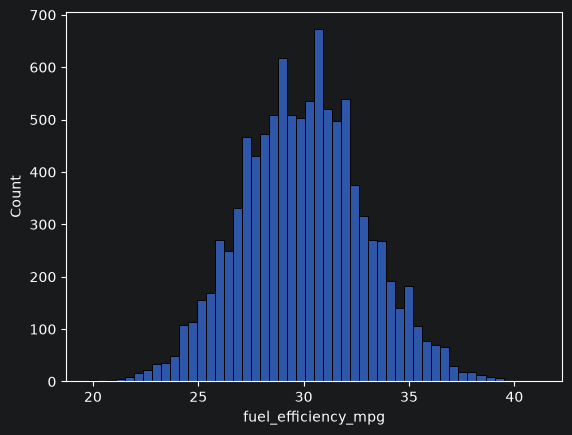

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64
assimetria (skew): 0.081


In [3]:
sns.histplot(df[target], bins=50)
plt.show()
print(df[target].describe())
print('assimetria (skew):', round(df[target].skew(), 3))
# skew perto de 0 + histograma em sino => NÃO tem cauda longa

In [4]:
# Question 1
# There's one column with missing values. What is it?

#'engine_displacement'
#'horsepower' -
#'vehicle_weight'
#'model_year'
df.isnull().sum() # Horsepower

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [5]:
# Question 2
# What's the median (50% percentile) for variable 'horsepower'?

# 204
# 254 - median
# 304
# 354

df['horsepower'].median() # -254

np.float64(254.0)

In [6]:
def split_data(df, seed):
    # exatamente o split da aula: 60% / 20% / 20%
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def prepare_X(df, fill_value):
    # só 'horsepower' tem NaN, então o fillna só afeta ela
    return df[base].fillna(fill_value).values


def train_linear_regression(X, y, r=0.0):
    # r = 0 -> sem regularização
    # ATENÇÃO: sem .round(1) aqui (isso arredondava as features e distorcia o modelo)
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

com 0 -> 2.205293194751098 -> arredondado: 2.205
com média -> 2.201817484568115 -> arredondado: 2.202
{'com 0': np.float64(2.205), 'com média': np.float64(2.202)}


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

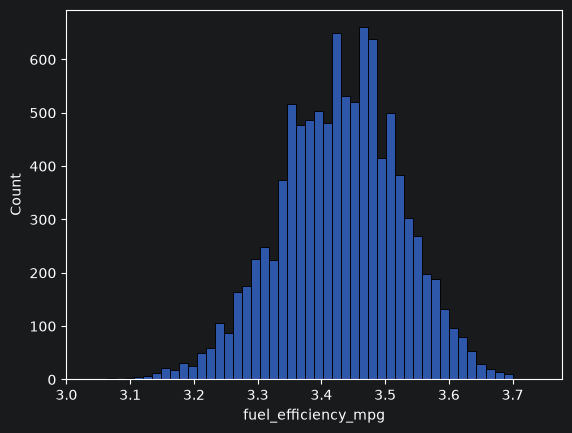

In [7]:
# Prepare and split the dataset
# Shuffle the filtered dataset and create the split exactly as in the lecture:

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

gasolina = np.log1p(df.fuel_efficiency_mpg)
# Question 3
# We need to deal with missing values for the column from Q1.
# We have two options: fill it with 0 or with the mean of this variable.
# Try both options. For each, train a linear regression model without regularization using the code from the lessons.
# For computing the mean, use the training only!
# Use the validation dataset to evaluate the models and compare the RMSE of each option.
# Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
# Which option gives better RMSE?
# Options:

# With 0
# With mean
# Both are equally good - Arredondando para 3 casas decimais.
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

df_train, df_val, df_test = split_data(df, seed=42)

y_train = df_train[target].values
y_val = df_val[target].values

mean_hp = df_train['horsepower'].mean()   # média só do treino!

resultados_q3 = {}
for nome, fill in [('com 0', 0), ('com média', mean_hp)]:
    X_train = prepare_X(df_train, fill)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, fill)      # mesmo valor de preenchimento na validação
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    resultados_q3[nome] = round(score, 3)
    print(nome, '->', score, '-> arredondado:', round(score, 3))

print(resultados_q3)
# nulos                            = 0.006321050840015859
# df['fuel_efficiency_mpg'].mean() = 0.006321059496439604
# Na questão pede para arrendodar ate 3 casas decimais então levando em consideração isso os dois são igualmentes bons.
sns.histplot(gasolina, bins=50)

In [8]:
# Question 4
# Now let's train a regularized linear regression.
# For this question, fill the NAs with 0.
# Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
# Use RMSE to evaluate the model on the validation dataset.
# Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
# Which r gives the best RMSE?
# If multiple options give the same best RMSE, select the smallest r.

# Options:

# 0
# 0.01
# 0.1
# 1
# 5
# 10
# 100

def train_linear_regression_r(X,y, r):
    one = np.ones(X.shape[0])
    X = np.column_stack([one,X]).round(1)

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

scores_q4 = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    scores_q4[r] = round(rmse(y_val, y_pred), 4)
    print(r, scores_q4[r])

# empate -> menor r (a chave (score, r) já faz isso)
melhor_r = min(scores_q4, key=lambda r: (scores_q4[r], r))
print('Melhor r:', melhor_r)

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292
Melhor r: 0


In [9]:
def train_linear_regression(X, y):
    one = np.ones(X.shape[0])
    X = np.column_stack([one, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

scores_q5 = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test = split_data(df, seed)

    y_train = df_train[target].values
    y_val = df_val[target].values

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)      # sem regularização

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    s = rmse(y_val, y_pred)
    scores_q5.append(s)
    print(seed, s)

std = np.std(scores_q5)
print('std:', std, '-> arredondado:', round(std, 3))
# Question 5
# We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
# What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
# Round the result to 3 decimal digits (round(std, 3))
# What's the value of std?

# 0.006
# 0.016
# 0.029
# 0.036
# Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.

0 2.2392041430461465
1 2.2021128210838907
2 2.163419778753095
3 2.2043588768539144
4 2.2018800943312926
5 2.2457851509084974
6 2.269721207952404
7 2.190794599933433
8 2.2166112016864443
9 2.207036592817851
std: 0.028781274078187116 -> arredondado: 0.029


In [11]:

df_train, df_val, df_test = split_data(df, seed=9)

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([df_train[target].values, df_val[target].values])
y_test = df_test[target].values

X_full_train = prepare_X(df_full_train)
w0, w = train_linear_regression(X_full_train, y_full_train)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)    # compara com y_TEST (não y_val)
print('RMSE teste:', score, '-> arredondado:', round(score, 3))
# Question 6
# Split the dataset like previously, use seed 9.
# Combine train and validation datasets.
# Fill the missing values with 0 and train a model with r=0.001.
# What's the RMSE on the test dataset?
# Options:

# 0.236
# 2.236
# 22.10
# 221.0

RMSE teste: 2.2357747027994606 -> arredondado: 2.236
